In [1]:
import os 
# os.environ['CUDA_VISIBLE_DEVICES'] = "" # set if you don't want to use GPU
import pandas as pd
import numpy as np
import tensorflow as tf
#os.environ['TRANSFORMERS_CACHE'] = "/home/iwe3/moritz/cache/" 
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# import umap

2025-07-31 11:11:55.271249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753953115.282775 1177509 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753953115.286318 1177509 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753953115.296504 1177509 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753953115.296513 1177509 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753953115.296515 1177509 computation_placer.cc:177] computation placer alr

In [ ]:
df = pd.read_csv('../../data/seq_training_data.csv')
df_info = pd.read_csv('/home/iwe18/Documents/joh/PhD/projects/EvoDenovo/info_db.csv')
df['PDB_ID'] = df['name'].apply(lambda x: x.split('_')[2])
merged_df = pd.merge(df, df_info, left_on='PDB_ID',right_on='name', how='inner')

In [4]:
from transformers import TFAutoModelForSequenceClassification
from transformers import EsmTokenizer, TFEsmModel, TFEsmForMaskedLM
#model_checkpoint = "facebook/esm2_t6_8M_UR50D"  # use larger in real use case
# model_checkpoint = "facebook/esm2_t36_3B_UR50D"
model_checkpoint = "facebook/esm2_t33_650M_UR50D"
#model_checkpoint = "facebook/esm2_t30_150M_UR50D"
tokenizer = EsmTokenizer.from_pretrained(model_checkpoint)
model = TFEsmModel.from_pretrained(model_checkpoint)

I0000 00:00:1753953179.027804 1177509 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4045 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:08:00.0, compute capability: 8.6
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFEsmModel: ['lm_head.layer_norm.bias', 'lm_head.dense.weight', 'esm.embeddings.position_ids', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.dense.bias']
- This IS expected if you are initializing TFEsmModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFEsmModel from a PyTorch model that you expect to be exactly identical (e.g. initializ

In [5]:
batch_size = 32
embeddings = np.zeros((len(df), 1280))
embeddings_per_aa = np.zeros((len(df), 252, 1280))

for batch in tqdm(range(0, len(df.sequence.values), batch_size)):     
    inputs = tokenizer(df.sequence.values[batch:batch+batch_size].tolist(), return_tensors='tf', max_length=df.sequence.str.len().max()+2, padding='max_length')
    outputs = model(inputs)
    embeddings_per_aa[batch:batch+batch_size] = outputs.last_hidden_state.numpy()
    embeddings[batch:batch+batch_size] = outputs.pooler_output.numpy()
    
with open('embeddings.npy', 'wb') as f:
    np.save(f, embeddings)

AttributeError: 'DataFrame' object has no attribute 'sequence'

In [2]:
import umap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

/home/iwe18/anaconda3/envs/tf-gpu/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-24 12:35:12.808759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 12:35:12.822001: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 12:35:12.822020: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-24 12:35:12.831254: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow 

In [3]:
with open('embeddings.npy', 'rb') as f:
    embeddings = np.load(f)

In [11]:
X_r_umap = umap.UMAP().fit_transform(embeddings)


In [12]:
df['comp_2_umap'] = X_r_umap[:,0]
df['comp_1_umap'] = X_r_umap[:,1]

merged_df['comp_2_umap'] = X_r_umap[232:,0]
merged_df['comp_1_umap'] = X_r_umap[232:,1]

nat_df = merged_df[merged_df['type']==0]
val_counts = merged_df.organism.value_counts()

In [13]:
# scaled_embedding = reducer.fit_transform(my_scaled_data)
def add_cosmetics(title='', 
                  xlabel='', ylabel='',ax=None,grid=False,my_col ='0.2'):
    plt.title(title, fontsize=30,fontname='Arial', weight='bold', color=my_col)
    plt.xlabel(xlabel, fontsize=30,fontname='Arial', weight='bold', color=my_col)
    plt.ylabel(ylabel, fontsize=30,fontname='Arial', weight='bold', color=my_col)
    plt.xticks(fontsize=25,fontname='Arial', weight='bold', color=my_col)
    plt.yticks(fontsize=25,fontname='Arial', weight='bold', color=my_col)
    if grid:    
        plt.grid(color='black',axis='both',linestyle=':',linewidth=0.5,which='major')

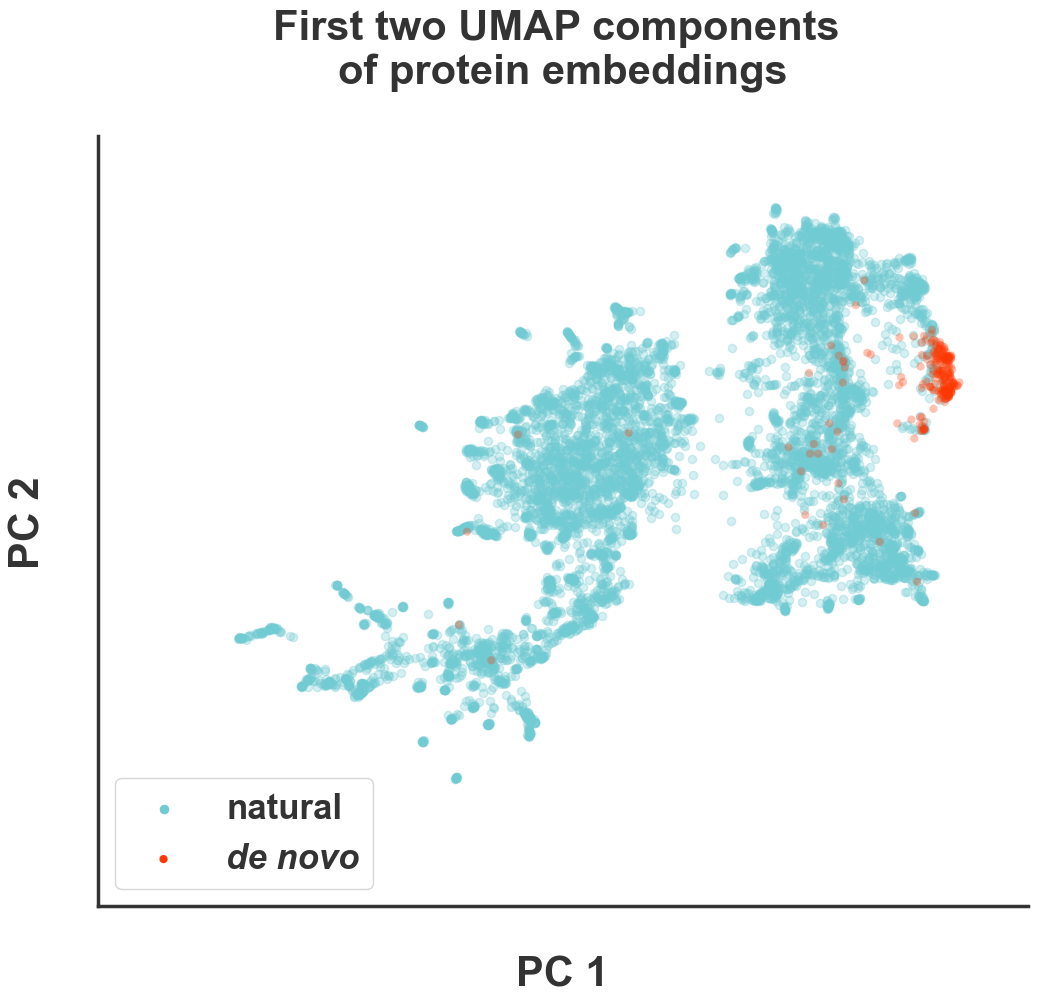

In [15]:

alpha = 0.3
scatter_dot = 35

fig, ax = plt.subplots(1,1,figsize=(12,10))

plt.scatter(df[df.type == 0].comp_1_umap, df[df.type == 0].comp_2_umap, s=scatter_dot, alpha=alpha, c='#71cbd3',label='natural')
plt.scatter(df[df.type == 1].comp_1_umap, df[df.type == 1].comp_2_umap, s=scatter_dot, alpha=alpha, label='de novo',c='#ff3700', edgecolor='none')


plt.legend()
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('First two umap components of protein embeddings')

add_cosmetics(title='First two UMAP components \nof protein embeddings\n',xlabel='\nPC 1',ylabel='PC 2\n')

ax.tick_params(width=2.5,length=10,pad=10, color='0.2')
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(2.5)
    ax.spines[axis].set_color('0.2')
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([])
plt.yticks([])


ax.set_ylim(0,18)
ax.set_xlim(0,18)
# ax.set_ylim(2,17)
# ax.set_xlim(-5,11)

#get handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

order = [0,1]

plt.rc('font',family='Arial',weight='bold')
plt.rc('legend')
l = ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc=3, prop={'size': 25})

for text in l.get_texts():
    text.set_color("0.2")
    
# l.get_texts()[2].set_style('italic')
l.get_texts()[1].set_style('italic')
    
for leg in l.legend_handles:
    leg.set_alpha(1)
    
    
plt.savefig('UMAP.png',dpi=300,bbox_inches='tight')